In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
from scipy import stats

In [2]:
# --- import data: bottleneck computed in 2 ways---
ABEL_24    = pd.read_csv('Abel_Nb_24hpi.csv')
LEONARD_24 = pd.read_csv('Leonard_Nb_24hpi.csv')
ABEL_48    = pd.read_csv('Abel-Nb_48hpi.csv')
LEONARD_48 = pd.read_csv('Leonard_Nb_48hpi.csv')

# ---- 24 hpi: ratio = Abel / Leonard (lung) ----
abel24 = ABEL_24.rename(columns={"Nb_bottleneck_size": "Abel"})
leo24  = LEONARD_24.rename(columns={"lung": "Leonard_lung"})

# ---- 48 hpi: ratios for lung and blood ----
abel48 = ABEL_48.rename(columns={"group": "condition", "lung": "Abel_lung", "blood": "Abel_blood"})
leo48  = LEONARD_48.rename(columns={"lung": "Leonard_lung","blood": "Leonard_blood"})

In [3]:
# ---------- Ratios ----------
# 24 hpi: Abel (single bottleneck column) / Leonard lung
df24 = pd.merge(leo24[["label", "condition", "mouse", "Leonard_lung"]], abel24[["label", "Abel"]], on="label", how="inner")
df24["ratio"] = df24["Abel"] / df24["Leonard_lung"]

# 48 hpi: lung + blood
df48 = pd.merge(leo48[["label", "condition", "mouse", "Leonard_lung", "Leonard_blood"]],
    abel48[["label", "condition", "mouse", "Abel_lung", "Abel_blood"]], on="label", how="inner", suffixes=("_leo", "_abel"))

# reconcile if the two files name the condition/mouse columns differently
df48["condition"] = df48["condition_leo"].combine_first(df48["condition_abel"])
df48["mouse"]     = df48["mouse_leo"].combine_first(df48["mouse_abel"])

df48["ratio_lung"]  = df48["Abel_lung"]  / df48["Leonard_lung"]
df48["ratio_blood"] = df48["Abel_blood"] / df48["Leonard_blood"]

In [4]:
# ---------- Sorting helpers ----------
def label_num(label: str) -> int:
    m = re.search(r"#(\d+)", str(label))
    return int(m.group(1)) if m else 10**9

def sort_df_for_plot(df: pd.DataFrame, ratio_col: str) -> pd.DataFrame:
    out = df.copy()
    out = out.replace([np.inf, -np.inf], np.nan).dropna(subset=[ratio_col, "label", "condition"])
    out["label_num"] = out["label"].map(label_num)

    # order conditions: noDox then Dox, else alphabetical
    def cond_key(x):
        s = str(x).lower()
        return (0 if s == "nodox" else 1 if s == "dox" else 2, str(x))
    conds = sorted(out["condition"].unique(), key=cond_key)
    cond_order = {c: i for i, c in enumerate(conds)}
    out["cond_order"] = out["condition"].map(cond_order)

    out = out.sort_values(["cond_order", "label_num", "label"]).reset_index(drop=True)
    out["pos"] = np.arange(len(out))
    return out

In [5]:
# --- Plot only (assumes df24 has "ratio", df48 has "ratio_lung"/"ratio_blood") ---
# Requires: label_num() from earlier (or re-define it here) + numpy as np + matplotlib.pyplot as plt
def plot_ratio(ax, df, ratio_col, cond_value, panel_letter=None):
    d = df.copy()
    d["cond_lc"] = d["condition"].astype(str).str.lower()
    d = d[d["cond_lc"] == str(cond_value).lower()].copy()

    d = d.replace([np.inf, -np.inf], np.nan).dropna(subset=[ratio_col, "label"])
    d["label_num"] = d["label"].map(label_num)
    d = d.sort_values(["label_num", "label"]).reset_index(drop=True)

    pos = np.arange(len(d))
    ax.bar(pos, d[ratio_col])

    ax.set_xticks(pos)
    ax.set_xticklabels(d["label"], rotation=45, fontsize = 18)
    ax.tick_params(axis='y', labelsize=14)
    ax.set_ylabel("$\\frac{N_b(\mathrm{Method\, 1})}{N_b(\mathrm{Method\, 2})}$", fontsize = 32)

    if panel_letter is not None:
        ax.text(-0.12, 1.06, f"{panel_letter}", transform=ax.transAxes, fontsize=24, fontweight="bold")

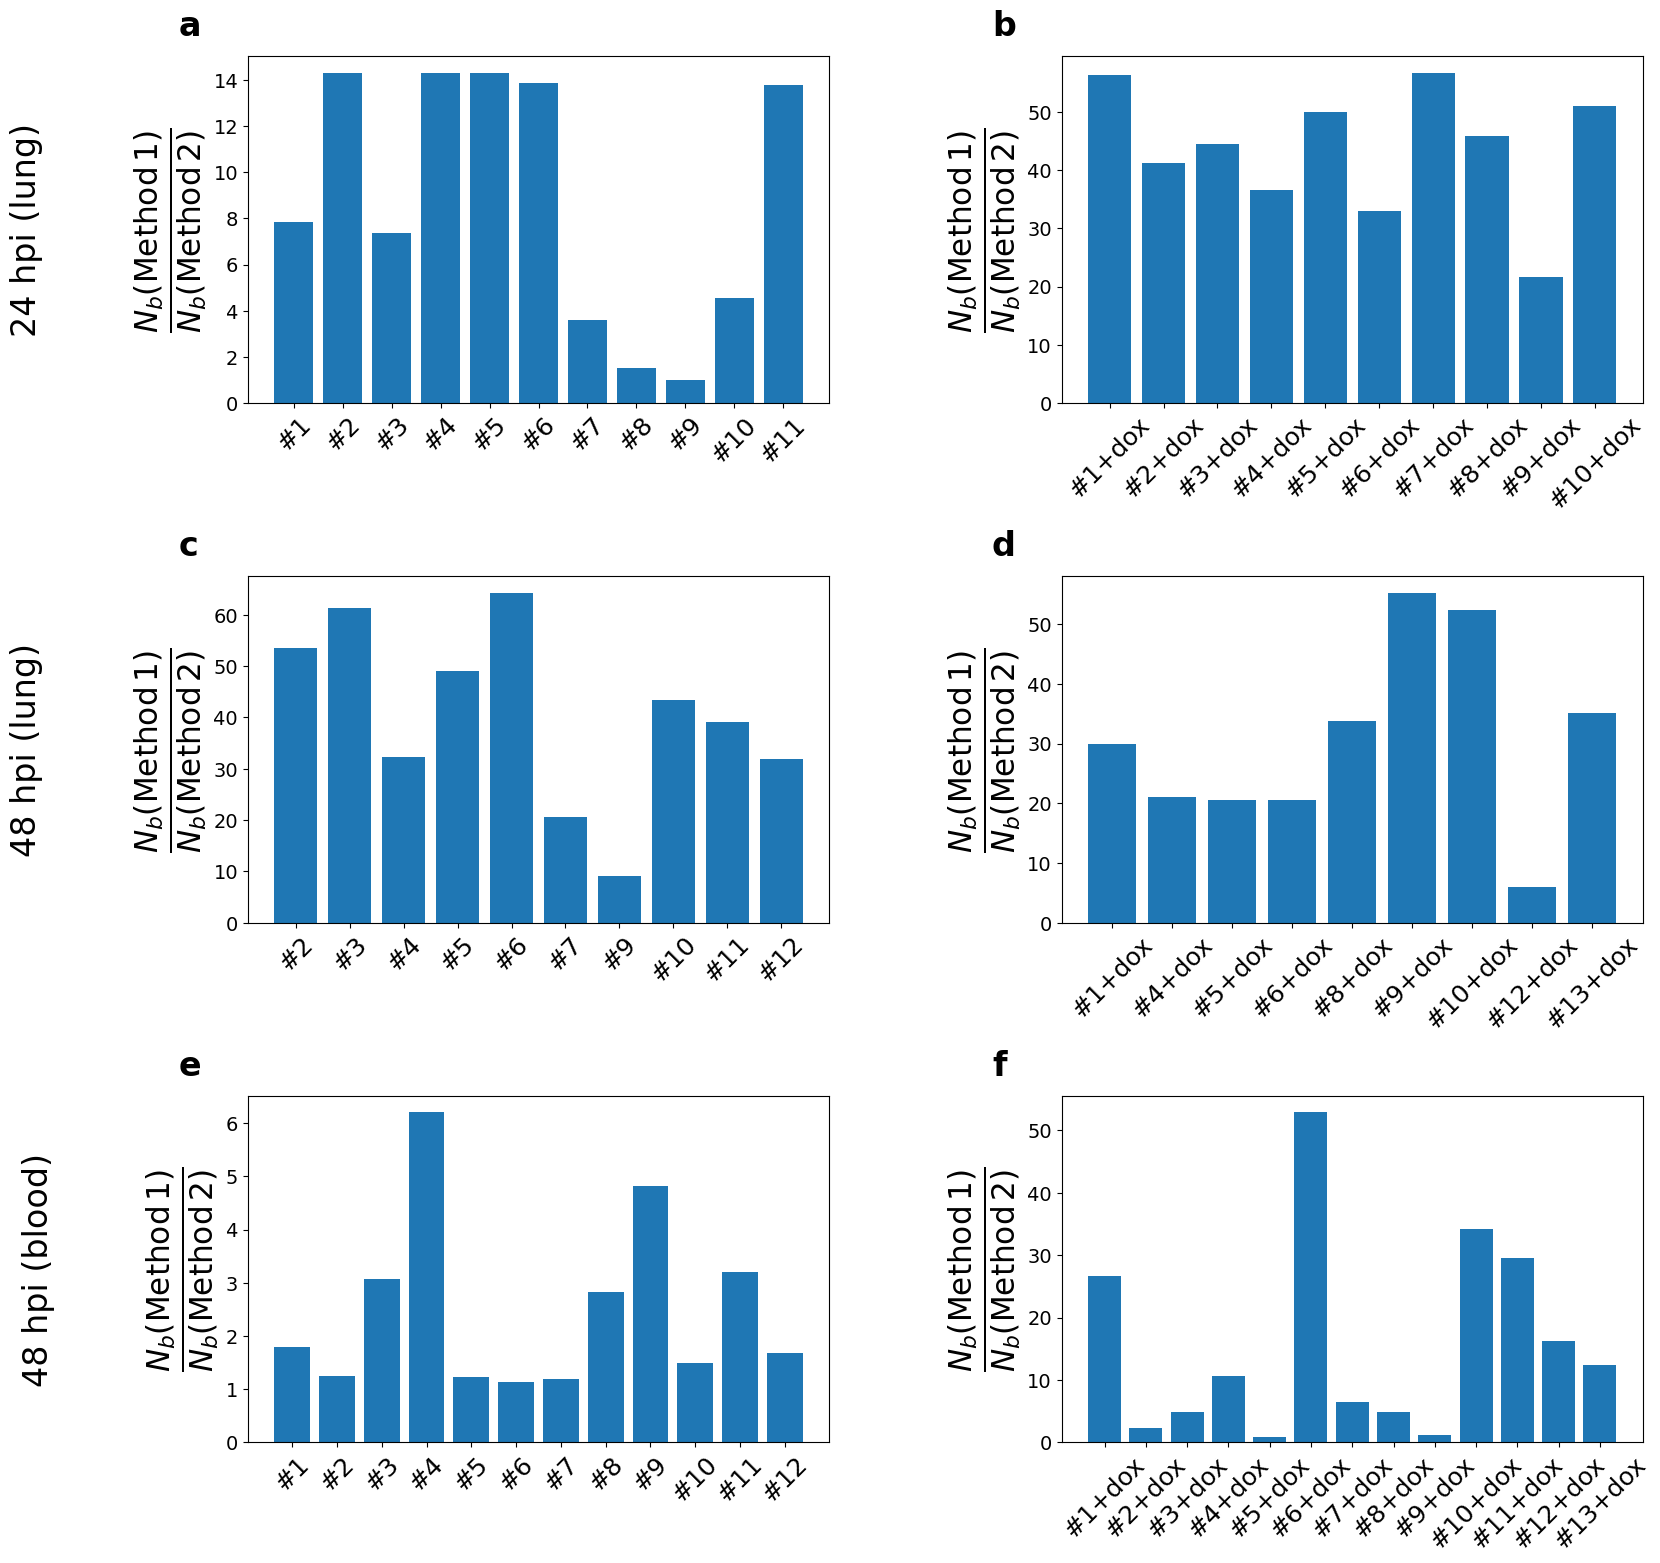

In [6]:
# rows = (title, dataframe, ratio column)
rows = [("24 hpi (lung)",  df24, "ratio"), ("48 hpi (lung)",  df48, "ratio_lung"), ("48 hpi (blood)", df48, "ratio_blood"),]
conds = ["noDox", "Dox"] # columns = conditions

fig, axes = plt.subplots(len(rows), len(conds), figsize=(18, 18))
plt.subplots_adjust(hspace = 0.5, wspace = 0.4)

letters = list("abcdef")
k = 0
for r, (row_title, df, ratio_col) in enumerate(rows):
    for c, cond in enumerate(conds):
        ax = axes[r, c]
        plot_ratio(ax, df, ratio_col, cond, panel_letter=letters[k])
        k += 1

        # row labels on the left margin
        if c == 0:
           ax.annotate(row_title, xy=(0, 0.5), xytext=(-ax.yaxis.labelpad - 60, 0), xycoords=ax.yaxis.label, 
                       textcoords='offset points', ha='right', va='center', rotation=90, fontsize = 24)

plt.show()

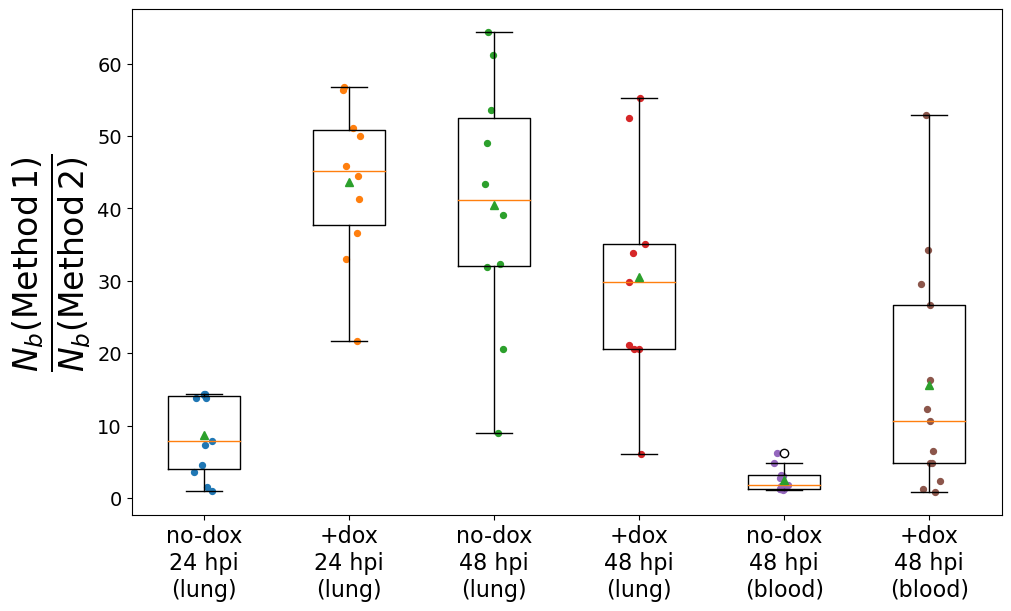

In [14]:
# One figure: 6 boxplots side-by-side with multi-line x-tick labels
# Assumes df24 has "ratio"; df48 has "ratio_lung" and "ratio_blood"
def _vals(df, ratio_col, cond):
    m = df["condition"].astype(str).str.lower().eq(str(cond).lower())
    return (df.loc[m, ratio_col].replace([np.inf, -np.inf], np.nan).dropna().astype(float).to_numpy())

# (condition, title_for_tick, dataframe, ratio_col)
boxes = [("noDox", "no-dox\n24 hpi\n(lung)",  df24, "ratio"), ("Dox", "+dox\n24 hpi\n(lung)", df24, "ratio"),
         ("noDox", "no-dox\n48 hpi\n(lung)",  df48, "ratio_lung"), ("Dox", "+dox\n48 hpi\n(lung)", df48,"ratio_lung"),
         ("noDox", "no-dox\n48 hpi\n(blood)", df48, "ratio_blood"), ("Dox", "+dox\n48 hpi\n(blood)", df48, "ratio_blood"),]

data   = [_vals(df, ratio_col, cond) for cond, _, df, ratio_col in boxes]
labels = [lab for _, lab, _, _ in boxes]

fig, ax = plt.subplots(1, 1, figsize=(10, 6), constrained_layout=True)
ax.boxplot(data, labels=labels, showmeans=True, showfliers=True)

# Optional: overlay individual points (comment out if you don't want it)
for i, x in enumerate(data, start=1):
    jitter = (np.random.rand(len(x)) - 0.5) * 0.15
    ax.scatter(i + jitter, x, s=18)

ax.set_ylabel("$\\frac{N_b(\mathrm{Method\, 1})}{N_b(\mathrm{Method\, 2})}$", fontsize=34)
ax.tick_params(axis="x", labelsize=16)
ax.tick_params(axis='y', labelsize=14)
plt.show()

In [ ]:
def _get_case_values(df, ratio_col, cond_value):
    d = df.copy()
    d["cond_lc"] = d["condition"].astype(str).str.lower()
    d = d[d["cond_lc"] == str(cond_value).lower()]
    x = d[ratio_col].replace([np.inf, -np.inf], np.nan).dropna().astype(float).to_numpy()
    return x

def one_sample_summary(x, mu0):
    n = len(x)
    out = {"n": n, "mean": np.nan if n == 0 else float(np.mean(x)), 
           "median": np.nan if n == 0 else float(np.median(x)), "sd": np.nan if n < 2 else float(np.std(x, ddof=1)),}

    # One-sample t-test: H0 mean(x) = mu0
    if n >= 2:
        t = stats.ttest_1samp(x, popmean=mu0, nan_policy="omit")
        out["t_stat"] = float(t.statistic)
        out["t_pvalue"] = float(t.pvalue)

        # 95% CI for the mean (t-interval)
        se = out["sd"] / np.sqrt(n)
        tcrit = stats.t.ppf(0.975, df=n - 1)
        out["mean_ci95_low"] = out["mean"] - tcrit * se
        out["mean_ci95_high"] = out["mean"] + tcrit * se
    else:
        out["t_stat"] = np.nan
        out["t_pvalue"] = np.nan
        out["mean_ci95_low"] = np.nan
        out["mean_ci95_high"] = np.nan

    # Wilcoxon signed-rank on differences: H0 median(diff) = 0 (under symmetry)
    # This is often used as a nonparametric alternative to the t-test.
    if n >= 1:
        diff = x - mu0
        if np.allclose(diff, 0):
            out["wilcoxon_stat"] = np.nan
            out["wilcoxon_pvalue"] = np.nan
        else:
            try:
                w = stats.wilcoxon(diff, zero_method="wilcox", alternative="two-sided", mode="auto")
                out["wilcoxon_stat"] = float(w.statistic)
                out["wilcoxon_pvalue"] = float(w.pvalue)
            except ValueError:
                out["wilcoxon_stat"] = np.nan
                out["wilcoxon_pvalue"] = np.nan
    else:
        out["wilcoxon_stat"] = np.nan
        out["wilcoxon_pvalue"] = np.nan

    return out

In [7]:
results = []
letters = list("abcdef")
k = 0

for row_title, df, ratio_col in rows:
    mu0 = 13.333 if ratio_col == "ratio" else 26.666  # 24 hpi vs 48 hpi
    for cond in conds:
        x = _get_case_values(df, ratio_col, cond)
        summ = one_sample_summary(x, mu0)
        results.append({"case": letters[k], "row": row_title, "condition": cond, "mu0": mu0, **summ})
        k += 1

test_table = pd.DataFrame(results)
test_table

,case,row,condition,mu0,n,mean,median,sd,t_stat,t_pvalue,mean_ci95_low,mean_ci95_high,wilcoxon_stat,wilcoxon_pvalue
0,a,24 hpi (lung),noDox,13.333,11,8.763462,7.854047,5.510453,-2.750308,2.046744e-02,5.061490,12.465435,15.0,0.123047
1,b,24 hpi (lung),Dox,13.333,10,43.688685,45.142231,10.976437,8.745379,1.079077e-05,35.836615,51.540755,0.0,0.001953
2,c,48 hpi (lung),noDox,26.666,10,40.450504,41.211676,17.573898,2.480407,3.496806e-02,27.878894,53.022113,9.0,0.064453
3,d,48 hpi (lung),Dox,26.666,9,30.541038,29.861067,15.857499,0.733099,4.844229e-01,18.351885,42.730191,16.0,0.496094
4,e,48 hpi (blood),noDox,26.666,12,2.490110,1.738014,1.624096,-51.565752,1.794606e-14,1.458209,3.522012,0.0,0.000488
5,f,48 hpi (blood),Dox,26.666,13,15.624725,10.578935,15.813598,-2.517446,2.703569e-02,6.068663,25.180787,18.0,0.057373
